<img src="../pic/CU.png" style="width: 100%; display: block; margin: auto;">

# Курс по прогнозированию временных рядов
# Неделя 5.
# Что происходит внутри `.fit()` и почему это долго

Вы уже умеете обучать SARIMA: `SARIMAX(y, order=..., seasonal_order=...).fit()`.
Обычно на этом знакомство и заканчивается — до первого случая, когда вызов
`auto_arima` на часовых данных считается сорок минут, и на вопрос «почему?»
приходится отвечать словом «медленно».

Этот ноутбук снимает с `.fit()` чёрный ящик. К концу вы сможете ответить на
«почему долго» не эмоцией, а перечислением этапов и указанием на **конкретный
аргумент**, который стоит поменять.

## Что мы разберём

| Раздел | Вопрос, на который отвечаем |
|---|---|
| 0 | Какие данные берём и почему именно их |
| 1 | Что вообще оценивается: полный список параметров SARIMAX |
| 2 | Четыре этапа обучения, каждый с замером времени |
| 3 | Откуда берётся сложность: размерность вектора состояния |
| 4 | Эмпирические кривые: время от $n$, от $m$, от $p+q$ |
| 5 | Рычаги ускорения и цена каждого |
| 6 | Одна и та же модель в четырёх библиотеках |

🔍 Чего сегодня **не** будет: подбора порядков (это ноутбук `02`) и разбора
алгоритма Хайндмана–Хандакара внутри `auto_arima` (это ноутбук `03`). Здесь мы
всегда знаем, какую модель обучаем, — и смотрим только на то, **сколько это
стоит**.

> **Соглашение об оформлении.** Блоки, начинающиеся с 🔍, — это то, на что стоит
> обратить внимание особо: там прячутся типичные ошибки новичков.

> **⏱** — этой пометкой отмечены ячейки, которые считаются заметно дольше
> секунды. Рядом указано ожидаемое время.

In [1]:
import time
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from statsmodels.tsa.arima.estimators.hannan_rissanen import hannan_rissanen
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Предупреждения о несошедшемся оптимизаторе здесь ожидаемы и только мешают
# читать вывод: мы намеренно обучаем заведомо неудобные спецификации.
warnings.filterwarnings("ignore")

plt.rcParams["figure.figsize"] = (11, 4)
plt.rcParams["axes.grid"] = True
plt.rcParams["figure.dpi"] = 110

import statsmodels

print("statsmodels:", statsmodels.__version__)
print("pandas:     ", pd.__version__)
print("numpy:      ", np.__version__)

statsmodels: 0.14.6
pandas:      2.3.3
numpy:       2.4.6


---
# 0. Данные: спрос на электроэнергию в Виктории

Сквозной ряд первых трёх ноутбуков — `vic_elec`: потребление электроэнергии в
австралийском штате Виктория. В исходном файле данные получасовые
(52 608 наблюдений за три года), мы агрегируем их до **дневных**.

Почему именно этот ряд:

* у него есть очевидная недельная сезонность ($m = 7$) — рабочие дни против
  выходных;
* есть осмысленные внешние переменные (температура, праздники) — они
  понадобятся в разделе 1, чтобы показать $\beta$-коэффициенты;
* он **достаточно длинный** ($n \approx 1100$), чтобы время обучения было
  заметно глазом. На ряде из 60 точек всё считается мгновенно, и разговор о
  вычислительной сложности превращается в теорию.

In [2]:
raw = pd.read_csv("../data/vic_elec.csv", parse_dates=["Time", "Date"])
raw.head(3)

,Time,Demand,Temperature,Date,Holiday
0,2011-12-31 13:00:00+00:00,4382.825174,21.40,2012-01-01,True
1,2011-12-31 13:30:00+00:00,4263.365526,21.05,2012-01-01,True
2,2011-12-31 14:00:00+00:00,4048.966046,20.70,2012-01-01,True


Колонка `Time` — это UTC, а `Date` — местная календарная дата. Агрегируем
**по `Date`**: так каждый день собирается из «своих» получасовок и крайние дни
не оказываются обрезанными.

* `Demand` суммируем — это суммарный дневной спрос;
* `Temperature` усредняем;
* `Holiday` берём через `any` — день праздничный, если он помечен таковым.

Ещё делим спрос на 1000 — чисто для удобства: работать с числами порядка 200
приятнее, чем с 200 000. Масштаб ряда, вообще говоря, влияет на сходимость
оптимизатора, и это не пустая предосторожность.

In [3]:
daily = (
    raw.groupby("Date")
    .agg(
        Demand=("Demand", "sum"),
        Temperature=("Temperature", "mean"),
        Holiday=("Holiday", "any"),
    )
    .asfreq("D")  # явная дневная частота: без неё statsmodels ругается на индекс
)
daily["Demand"] /= 1e3

y = daily["Demand"]

print(f"наблюдений: {len(y)},  с {y.index.min():%Y-%m-%d} по {y.index.max():%Y-%m-%d}")
print(f"частота индекса: {y.index.freq},  пропусков: {y.isna().sum()}")
y.describe().round(2)

наблюдений: 1096,  с 2012-01-01 по 2014-12-31
частота индекса: <Day>,  пропусков: 0


count    1096.00
mean      223.94
std        25.48
min       161.10
25%       210.22
50%       223.80
75%       241.26
max       346.72
Name: Demand, dtype: float64

🔍 `asfreq("D")` — не косметика. `statsmodels` использует частоту индекса,
чтобы построить индекс будущих дат при прогнозе. Если частота не задана, модель
обучится, но `forecast()` вернёт результат с целочисленным индексом `1096, 1097, …`
вместо дат, и все графики поедут.

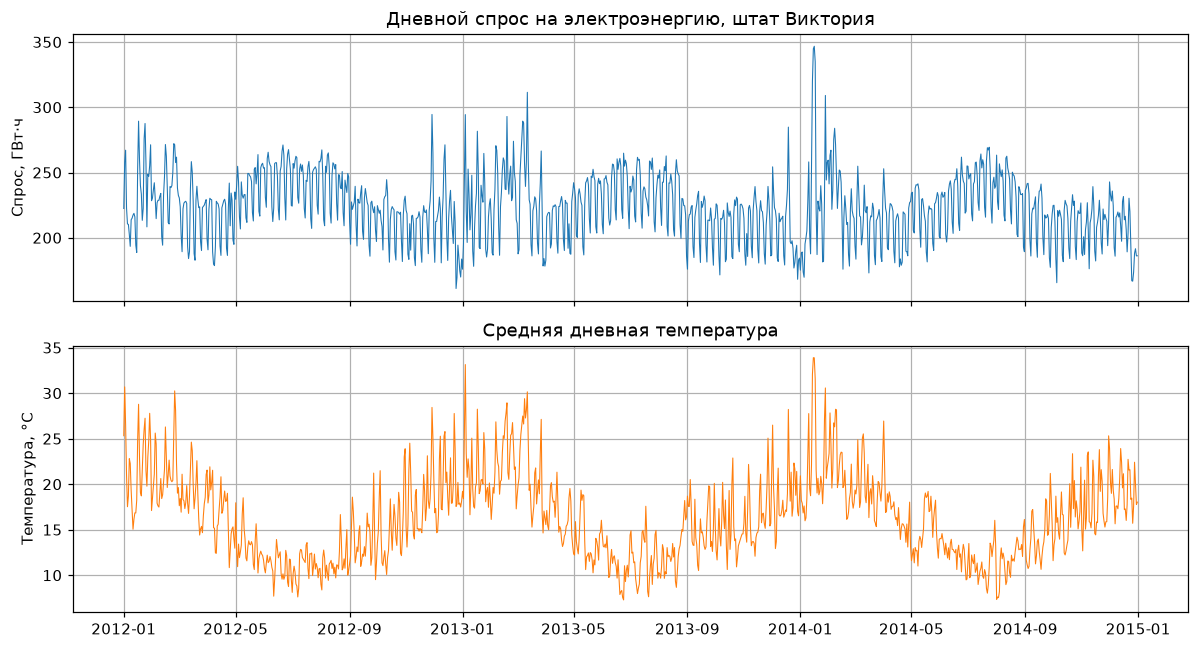

In [4]:
fig, axs = plt.subplots(2, 1, figsize=(11, 6), sharex=True)
axs[0].plot(y, lw=0.7)
axs[0].set_ylabel("Спрос, ГВт·ч")
axs[0].set_title("Дневной спрос на электроэнергию, штат Виктория")

axs[1].plot(daily["Temperature"], lw=0.7, color="C1")
axs[1].set_ylabel("Температура, °C")
axs[1].set_title("Средняя дневная температура")
fig.tight_layout()

Видно две вещи, которые пригодятся дальше: годовой цикл (летние пики спроса —
кондиционеры) и «мохнатость» линии — это недельная сезонность, на дневном
масштабе она сливается в толщину штриха.

---
# 1. Что вообще оценивается

## 1.1. Модель целиком

SARIMAX в `statsmodels` — это **регрессия с SARIMA-ошибками**:

$$ y_t = \beta' x_t + n_t $$

$$ \underbrace{\varphi_p(L)}_{\text{AR}}\ \underbrace{\Phi_P(L^m)}_{\text{сезонный AR}}\
   \underbrace{(1-L)^d (1-L^m)^D}_{\text{дифференцирование}}\ n_t
   = \underbrace{\theta_q(L)}_{\text{MA}}\ \underbrace{\Theta_Q(L^m)}_{\text{сезонный MA}}\ \varepsilon_t $$

где $L$ — оператор лага ($L y_t = y_{t-1}$), а полиномы устроены так:

$$ \varphi_p(L) = 1 - \varphi_1 L - \dots - \varphi_p L^p, \qquad
   \Phi_P(L^m) = 1 - \Phi_1 L^m - \dots - \Phi_P L^{Pm} $$

## 1.2. Полный список параметров

Оптимизатор ищет вектор из следующих чисел:

| Группа | Параметры | Сколько |
|---|---|---|
| AR | $\varphi_1, \dots, \varphi_p$ | $p$ |
| MA | $\theta_1, \dots, \theta_q$ | $q$ |
| Сезонный AR | $\Phi_1, \dots, \Phi_P$ | $P$ |
| Сезонный MA | $\Theta_1, \dots, \Theta_Q$ | $Q$ |
| Регрессоры | $\beta_1, \dots, \beta_{n_X}$ | $n_X$ = число столбцов `exog` |
| Тренд | константа и/или наклон (`trend='c'/'t'/'ct'`) | $c \in \{0,1,2\}$ |
| Дисперсия шума | $\sigma^2$ | 1 |

$$ \boxed{k = p + q + P + Q + n_X + c + 1} $$

🔍 Обратите внимание, чего в этом списке **нет**: там нет $d$, $D$ и $m$.
Дифференцирование — не параметр, а преобразование данных; период сезонности $m$
задаётся человеком. Из этого сразу следует важное: **увеличение $m$ с 7 до 365
не добавляет ни одного параметра.** Почему тогда обучение замедляется в сотни
раз — разбираемся в разделе 3.

## 1.3. Читаем `summary()` построчно

Обучим SARIMAX с тремя внешними переменными. Регрессоры выбраны содержательно:
спрос зависит от температуры **нелинейно** (растёт и в жару из-за кондиционеров,
и в холод из-за отопления), поэтому берём и `Temp`, и `Temp²`; плюс дамми на
рабочий день.

In [5]:
exog = pd.DataFrame(
    {
        "Temp": daily["Temperature"],
        "Temp2": daily["Temperature"] ** 2,
        # рабочий день = будни, не отмеченные как праздник
        "WorkDay": (~daily["Holiday"] & daily.index.dayofweek.isin(range(5))).astype(float),
    },
    index=daily.index,
)
exog.head(3)

,Temp,Temp2,WorkDay
Date,,,
2012-01-01,25.322917,641.250109,0.0
2012-01-02,30.689583,941.850525,0.0
2012-01-03,26.513542,702.967892,1.0


In [6]:
model = SARIMAX(
    y,
    exog=exog,
    order=(1, 1, 1),  # (p, d, q)
    seasonal_order=(1, 1, 1, 7),  # (P, D, Q, m)
    trend=None,  # без константы: она не идентифицируется при d >= 1
)
res = model.fit(disp=False)
res.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                     SARIMAX Results                                     
=========================================================================================
Dep. Variable:                            Demand   No. Observations:                 1096
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 7)   Log Likelihood               -3497.918
Date:                           Sun, 06 Sep 2026   AIC                           7011.835
Time:                                   10:24:01   BIC                           7051.772
Sample:                               01-01-2012   HQIC                          7026.952
                                    - 12-31-2014                                         
Covariance Type:                             opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Temp         -11.5874      0.284    -40.755      0.000     -12.145     -11.030
Temp2          0.3585      0.006     56.293      0.000       0.346       0.371
WorkDay       30.4558      0.774     39.331      0.000      28.938      31.973
ar.L1          0.6191      0.037     16.879      0.000       0.547       0.691
ma.L1         -0.8802      0.022    -39.558      0.000      -0.924      -0.837
ar.S.L7        0.0585      0.027      2.160      0.031       0.005       0.112
ma.S.L7       -0.9922      0.024    -41.513      0.000      -1.039      -0.945
sigma2        35.3159      1.181     29.899      0.000      33.001      37.631
===================================================================================
Ljung-Box (L1) (Q):                   0.06   Jarque-Bera (JB):               559.56
Prob(Q):                              0.80   Prob(JB):                         0.00
Heteroskedasticity (H):               0.87   Skew:                             0.00
Prob(H) (two-sided):                  0.20   Kurtosis:                         6.51
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

Разберём таблицу коэффициентов сверху вниз:

| Строка | Что это |
|---|---|
| `Temp`, `Temp2`, `WorkDay` | те самые $\beta$: по одному на каждый столбец `exog`. Читаются как в обычной регрессии |
| `ar.L1` | $\varphi_1$ — несезонный AR-коэффициент при лаге 1 |
| `ma.L1` | $\theta_1$ — несезонный MA-коэффициент при лаге 1 |
| `ar.S.L7` | $\Phi_1$ — сезонный AR, буква `S` и лаг 7 = $m$ |
| `ma.S.L7` | $\Theta_1$ — сезонный MA |
| `sigma2` | $\hat\sigma^2$ — оценка дисперсии шума $\varepsilon_t$ |

🔍 `sigma2` стоит в **той же таблице**, что и коэффициенты, со своим `std err`
и `P>|z|`. Это сбивает с толку: кажется, что это ещё один регрессор. Нет —
это масштаб шума, и проверять его на значимость бессмысленно (гипотеза
$\sigma^2 = 0$ означала бы, что ряд детерминирован).

Проверим формулу $k = p + q + P + Q + n_X + c + 1$ на числах:

In [7]:
p, d, q = model.order
P, D, Q, m = model.seasonal_order
n_X = exog.shape[1]
c = 0  # trend=None

k_formula = p + q + P + Q + n_X + c + 1

print("имена параметров:", model.param_names)
print(f"\nпо формуле:  {p} + {q} + {P} + {Q} + {n_X} + {c} + 1 = {k_formula}")
print(f"фактически:  len(res.params) = {len(res.params)}")
assert k_formula == len(res.params)

имена параметров: ['Temp', 'Temp2', 'WorkDay', 'ar.L1', 'ma.L1', 'ar.S.L7', 'ma.S.L7', 'sigma2']

по формуле:  1 + 1 + 1 + 1 + 3 + 0 + 1 = 8
фактически:  len(res.params) = 8


---
# 2. Четыре этапа обучения

Вызов `.fit()` разворачивается в четыре шага. Пройдём по ним и замерим каждый.

1. **Дифференцирование** ($d$, $D$) — привести ряд к стационарному виду.
2. **Стартовые приближения** — грубая, но быстрая оценка параметров, с которой
   стартует оптимизатор.
3. **Вычисление правдоподобия** — представить модель в пространстве состояний
   и один раз прогнать фильтр Калмана. Это то, что вызывается сотни раз.
4. **Численная оптимизация** — двигать параметры, пока правдоподобие растёт.

## 2.1. Этап 1: дифференцирование — дёшево

Это просто вычитание, $O(n)$:

In [8]:
t0 = time.perf_counter()
y_diff = y.diff(1).diff(7).dropna()  # (1-L)(1-L^7) y
t_diff = time.perf_counter() - t0

print(f"дифференцирование: {t_diff * 1000:.3f} мс")
print(f"было {len(y)} точек, стало {len(y_diff)} (потеряли d + D*m = {1 + 1 * 7})")

дифференцирование: 0.644 мс
было 1096 точек, стало 1088 (потеряли d + D*m = 8)


Миллисекунды. Этот этап никогда не бывает узким местом — держим в голове и
больше к нему не возвращаемся.

## 2.2. Этап 2: стартовые приближения

Оптимизатору нужна точка, из которой начинать. Считать её полноценным
максимальным правдоподобием было бы кругом в определении, поэтому используют
**дешёвые приближённые оценки**. Классика жанра — метод Ханнана–Риссанена:
сначала обычным МНК подгоняется длинная AR-модель, её остатки объявляются
оценкой $\varepsilon_t$, а потом МНК-регрессией по лагам $y$ и лагам этих
остатков сразу получаются и AR-, и MA-коэффициенты.

In [9]:
t0 = time.perf_counter()
hr_params, _ = hannan_rissanen(y_diff, ar_order=1, ma_order=1)
t_hr = time.perf_counter() - t0

print(f"Ханнан–Риссанен: {t_hr * 1000:.1f} мс")
print(f"  AR:     {hr_params.ar_params}")
print(f"  MA:     {hr_params.ma_params}")
print(f"  sigma2: {hr_params.sigma2:.2f}")

Ханнан–Риссанен: 4.5 мс
  AR:     [1.77000567]
  MA:     [-1.81209672]
  sigma2: 752.40


Единицы миллисекунд — это всего лишь пара МНК.

🔍 Посмотрите на полученный AR-коэффициент: он больше единицы. Это значит, что
оценка Ханнана–Риссанена вылетела **за границу области стационарности** —
такая модель не является допустимой ARMA. Дешёвые оценки этим грешат регулярно,
и именно поэтому `statsmodels` не берёт их как стартовую точку по умолчанию.
Его собственная эвристика консервативнее:

In [10]:
print("стартовая точка оптимизатора (model.start_params):")
pd.Series(model.start_params, index=model.param_names).round(4)

стартовая точка оптимизатора (model.start_params):


Temp      -10.7552
Temp2       0.3356
WorkDay    30.2697
ar.L1       0.3347
ma.L1      -0.5340
ar.S.L7    -0.0965
ma.S.L7    -0.6285
sigma2     69.7340
dtype: float64

Здесь AR/MA стартуют с нулей (или очень малых значений), а $\beta$ — с
МНК-оценок. Нули заведомо лежат внутри области стационарности, так что
оптимизатор гарантированно стартует из допустимой точки. Плата за
консервативность — лишние итерации, и в разделе 5 мы посмотрим, что будет,
если подсказать модели точку получше.

## 2.3. Этап 3: одно вычисление правдоподобия = один проход фильтра Калмана

Это ядро всего процесса. Модель переписывается в форме **пространства
состояний**:

$$ \begin{aligned}
y_t &= Z \alpha_t + \beta' x_t && \text{(уравнение наблюдения)} \\
\alpha_{t+1} &= T \alpha_t + R \eta_t && \text{(уравнение состояния)}
\end{aligned} $$

где $\alpha_t$ — ненаблюдаемый **вектор состояния** размерности $r$. Фильтр
Калмана проходит по ряду один раз, на каждом шаге обновляя оценку состояния и
накапливая вклад в логарифм правдоподобия.

Метод `model.loglike(params)` делает ровно один такой проход. Замерим его:

In [11]:
def time_loglike(mod, params=None, repeat=7):
    """Среднее время одного вычисления правдоподобия (= одного прохода фильтра Калмана)."""
    if params is None:
        params = mod.start_params
    mod.loglike(params)  # прогрев: первый вызов строит матрицы состояния
    t0 = time.perf_counter()
    for _ in range(repeat):
        mod.loglike(params)
    return (time.perf_counter() - t0) / repeat


t_loglike = time_loglike(model)
print(f"одно вычисление loglike: {t_loglike * 1000:.2f} мс")
print(f"размерность состояния r = model.k_states = {model.k_states}")

одно вычисление loglike: 3.01 мс
размерность состояния r = model.k_states = 17


Единицы миллисекунд. Само по себе — ничто. Но посмотрим, сколько раз это
вызывается.

## 2.4. Этап 4: численная оптимизация

По умолчанию `statsmodels` использует **L-BFGS** — квазиньютоновский метод.
На каждой итерации ему нужно значение функции и её градиент; градиент по $k$
параметрам считается численно, то есть ещё $\sim k$ вычислений правдоподобия.

Посмотрим на траекторию спуска. У `fit()` есть аргумент `disp=True`, но
L-BFGS печатает свой лог на уровне Fortran-кода, и в ячейку Jupyter он обычно
не попадает (уходит в терминал, из которого запущено ядро). Поэтому соберём лог
сами — через `callback`, который `statsmodels` вызывает после каждой итерации:

In [12]:
trace = []

mod_v = SARIMAX(y, exog=exog, order=(1, 1, 1), seasonal_order=(1, 1, 1, 7), trend=None)
# 🔍 transformed=False — обязательно! Оптимизатор работает в «развязанном»
# пространстве, где параметры не стеснены условиями стационарности, и callback
# получает вектор именно оттуда. Без этого флага loglike посчитает значение не в
# той точке, и трасса получится бессмысленной.
res_verbose = mod_v.fit(
    disp=False,
    callback=lambda params: trace.append(mod_v.loglike(params, transformed=False)),
)

log = pd.DataFrame({"итерация": range(1, len(trace) + 1), "loglik": np.round(trace, 3)})
log["прирост"] = log["loglik"].diff().round(4)
# показываем первые и последние строки: середина — монотонное однообразие
pd.concat([log.head(6), log.tail(4)])

,итерация,loglik,прирост
0,1,-3643.540,NaN
1,2,-3639.165,4.375
2,3,-3628.019,11.146
3,4,-3624.098,3.921
4,5,-3620.803,3.295
5,6,-3618.003,2.800
46,47,-3497.925,0.014
47,48,-3497.921,0.004
48,49,-3497.920,0.001
49,50,-3497.918,0.002


Text(0.5, 1.0, 'Траектория L-BFGS: почти всё выигрывается за первые итерации')

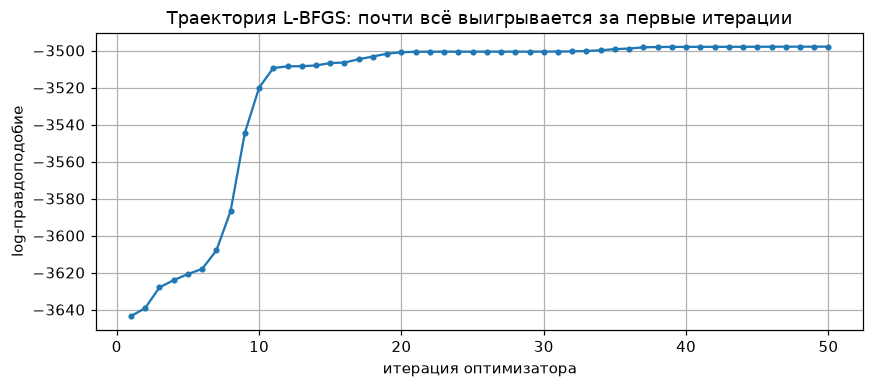

In [13]:
plt.figure(figsize=(9, 3.5))
plt.plot(log["итерация"], log["loglik"], "o-", ms=3)
plt.xlabel("итерация оптимизатора")
plt.ylabel("log-правдоподобие")
plt.title("Траектория L-BFGS: почти всё выигрывается за первые итерации")

🔍 Характерная картина: правдоподобие взлетает за первые несколько итераций,
а дальше десятки итераций уходят на четвёртый знак после запятой. Именно этот
«хвост» и подрезает `maxiter` — обычно почти бесплатно по качеству, но
«обычно» ≠ «всегда» (см. раздел 5.3).

Ключевые числа лежат в `mle_retvals`:

In [14]:
print("итераций оптимизатора (iterations):     ", res.mle_retvals["iterations"])
print("вычислений правдоподобия (fcalls):      ", res.mle_retvals["fcalls"])
print("сошёлся (converged):                    ", res.mle_retvals["converged"])
print(
    f"\nвычислений на одну итерацию: {res.mle_retvals['fcalls'] / res.mle_retvals['iterations']:.1f}"
    f"  (≈ 1 + k, где k = {len(res.params)} — цена численного градиента)"
)

итераций оптимизатора (iterations):      50
вычислений правдоподобия (fcalls):       522
сошёлся (converged):                     False

вычислений на одну итерацию: 10.4  (≈ 1 + k, где k = 8 — цена численного градиента)


## 2.5. Складываем всё вместе

Главная формула ноутбука:

$$ \boxed{\ T_{\text{fit}} \approx \underbrace{N_{\text{вычислений}}}_{\text{от оптимизатора}}
   \times \underbrace{T_{\text{loglike}}}_{\text{от фильтра Калмана}}\ } $$

Проверим её численно:

In [15]:
mod = SARIMAX(y, exog=exog, order=(1, 1, 1), seasonal_order=(1, 1, 1, 7), trend=None)
t0 = time.perf_counter()
r = mod.fit(disp=False)
t_fit = time.perf_counter() - t0

n_calls = r.mle_retvals["fcalls"]
predicted = n_calls * t_loglike

print(f"фактическое время fit:            {t_fit:.2f} с")
print(f"вычислений правдоподобия:         {n_calls}")
print(f"время одного вычисления:          {t_loglike * 1000:.2f} мс")
print(f"их произведение:                  {predicted:.2f} с")
print(f"необъяснённый остаток:            {t_fit - predicted:.2f} с")

фактическое время fit:            1.56 с
вычислений правдоподобия:         522
время одного вычисления:          3.01 мс
их произведение:                  1.57 с
необъяснённый остаток:            -0.02 с


🔍 Произведение объясняет **основную часть** времени, но не всё. Остаток —
накладные расходы, которые платятся один раз: построение матриц пространства
состояний, численное дифференцирование гессиана для стандартных ошибок
(`Covariance Type: opg` в `summary()`) и сглаживание для `fittedvalues`.
На больших задачах их доля падает, и формула становится точнее.

**Практический вывод.** Ускорить обучение можно ровно двумя способами:
уменьшить $T_{\text{loglike}}$ (раздел 3 — за счёт размерности состояния) или
уменьшить $N_{\text{вычислений}}$ (раздел 5 — за счёт оптимизатора и стартовой
точки). Третьего не дано.

---
# 3. Откуда берётся сложность

## 3.1. Цена одного прохода фильтра Калмана

Фильтр Калмана делает $n$ шагов, и на каждом перемножает матрицы размера
$r \times r$. Отсюда:

$$ T_{\text{loglike}} = O(n \cdot r^2) $$

— **линейно по длине ряда** и **квадратично по размерности состояния**.

## 3.2. Чему равно $r$

Для SARIMA$(p,d,q)(P,D,Q)_m$ в `statsmodels`:

$$ r = \max\bigl(p + P\,m,\ \ q + Q\,m + 1\bigr) \;+\; \underbrace{d + D\,m}_{\substack{\text{хранение уровней}\\ \text{для «раздифференцирования»}}} $$

Второе слагаемое появляется потому, что по умолчанию `statsmodels`
**не дифференцирует ряд явно**, а встраивает разности в модель состояния — это
позволяет использовать все $n$ наблюдений и корректно считать правдоподобие
исходного ряда. Цена — более длинный вектор состояния.

Проверим формулу на нескольких спецификациях:

In [16]:
specs = [
    ((1, 1, 1), (0, 0, 0, 0)),
    ((1, 1, 1), (1, 0, 1, 7)),
    ((1, 1, 1), (1, 1, 1, 7)),
    ((1, 1, 1), (1, 1, 1, 12)),
    ((1, 1, 1), (1, 1, 1, 24)),
    ((1, 1, 1), (1, 1, 1, 365)),
    ((3, 1, 3), (1, 1, 1, 7)),
]

rows = []
for order, sorder in specs:
    p, d, q = order
    P, D, Q, m = sorder
    mod_i = SARIMAX(y, order=order, seasonal_order=sorder, trend=None)
    rows.append(
        {
            "спецификация": f"({p},{d},{q})({P},{D},{Q})_{m}",
            "k (параметров)": p + q + P + Q + 1,
            "r по формуле": max(p + P * m, q + Q * m + 1) + d + D * m,
            "r фактически": mod_i.k_states,
        }
    )

pd.DataFrame(rows)

,спецификация,k (параметров),r по формуле,r фактически
0,"(1,1,1)(0,0,0)_0",3,3,3
1,"(1,1,1)(1,0,1)_7",5,10,10
2,"(1,1,1)(1,1,1)_7",5,17,17
3,"(1,1,1)(1,1,1)_12",5,27,27
4,"(1,1,1)(1,1,1)_24",5,51,51
5,"(1,1,1)(1,1,1)_365",5,733,733
6,"(3,1,3)(1,1,1)_7",9,19,19


🔍 **Главное наблюдение всего ноутбука.** Сравните две строки:

* SARIMA$(1,1,1)(1,1,1)_{24}$ — **5 параметров**, состояние размерности **51**;
* SARIMA$(1,1,1)(1,1,1)_{365}$ — **те же 5 параметров**, состояние размерности **733**.

(Пять — это четыре коэффициента $\varphi_1, \theta_1, \Phi_1, \Theta_1$ плюс
$\sigma^2$.)

Модели одинаково «сложны» с точки зрения статистики (одинаковое число степеней
свободы, сопоставимый риск переобучения), но одна считается в сотни раз дольше
другой. **$m$ входит в размерность состояния, а не в число параметров.**

Из этого растёт вся практика семинара 5: если сезонный период большой, сезонность
лучше вынести из SARIMA наружу — в регрессоры. К этому вернёмся в разделе 5.

---
# 4. Эмпирические кривые

Теория даёт $T_{\text{loglike}} = O(n \cdot r^2)$. Проверим на измерениях.

🔍 Мы намеренно замеряем **`loglike`, а не `fit`**. Время `fit` зависит ещё и
от того, сколько итераций понадобилось оптимизатору, а это число скачет от
спецификации к спецификации и зашумляет картину. `loglike` — чистая
вычислительная стоимость одного прохода.

## 4.1. Зависимость от длины ряда $n$

In [17]:
lengths = [100, 200, 400, 600, 800, 1096]
res_n = []
for n in lengths:
    mod_n = SARIMAX(y.iloc[:n], order=(1, 1, 1), seasonal_order=(1, 0, 1, 7), trend=None)
    res_n.append({"n": n, "r": mod_n.k_states, "loglike, мс": time_loglike(mod_n, repeat=15) * 1000})

df_n = pd.DataFrame(res_n)
df_n["мкс на точку ряда"] = (df_n["loglike, мс"] / df_n["n"] * 1000).round(3)
df_n.round(3)

,n,r,"loglike, мс",мкс на точку ряда
0,100,10,0.256,2.557
1,200,10,0.351,1.753
2,400,10,0.533,1.333
3,600,10,0.645,1.075
4,800,10,0.790,0.988
5,1096,10,0.989,0.902


🔍 Колонка «мкс на точку ряда» не постоянна, а падает. Это не нарушение
линейности: у каждого вызова есть **фиксированные** накладные расходы (сборка
матриц состояния, переход из Python в C), и на коротком ряде они составляют
заметную долю. Чем длиннее ряд, тем ближе цена к чистой линии — см. график
ниже, он практически прямой.

## 4.2. Зависимость от сезонного периода $m$

⏱ ~10 секунд.

In [18]:
periods = [7, 12, 24, 52, 168, 365]
res_m = []
for m in periods:
    mod_m = SARIMAX(y, order=(1, 1, 1), seasonal_order=(1, 0, 1, m), trend=None)
    res_m.append(
        {
            "m": m,
            "r": mod_m.k_states,
            "k": 5,
            "loglike, мс": time_loglike(mod_m, repeat=5) * 1000,
        }
    )

df_m = pd.DataFrame(res_m)
df_m["во сколько раз дороже m=7"] = (df_m["loglike, мс"] / df_m["loglike, мс"].iloc[0]).round(1)
df_m.round(2)

,m,r,k,"loglike, мс",во сколько раз дороже m=7
0,7,10,5,0.95,1.0
1,12,15,5,1.37,1.4
2,24,27,5,3.68,3.9
3,52,55,5,12.32,13.0
4,168,171,5,165.67,174.4
5,365,368,5,134.01,141.1


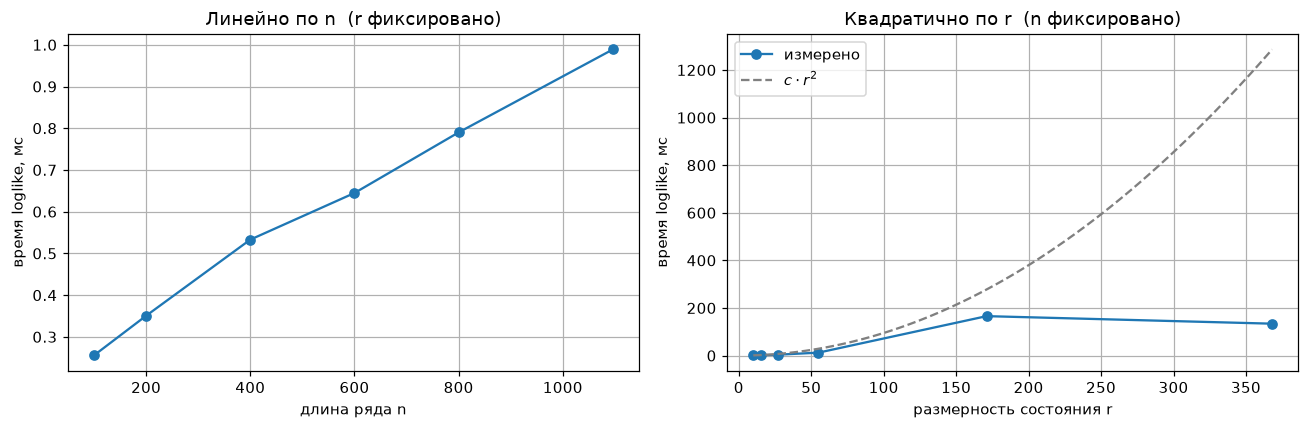

In [19]:
fig, axs = plt.subplots(1, 2, figsize=(12, 4))

axs[0].plot(df_n["n"], df_n["loglike, мс"], "o-")
axs[0].set(xlabel="длина ряда n", ylabel="время loglike, мс", title="Линейно по n  (r фиксировано)")

axs[1].plot(df_m["r"], df_m["loglike, мс"], "o-", label="измерено")
# Пристроим к первой точке чистую параболу c*r^2 — для сравнения формы кривой.
r0, t_0 = df_m["r"].iloc[0], df_m["loglike, мс"].iloc[0]
rr = np.linspace(df_m["r"].min(), df_m["r"].max(), 100)
axs[1].plot(rr, t_0 * (rr / r0) ** 2, "--", color="gray", label="$c\\cdot r^2$")
axs[1].set(
    xlabel="размерность состояния r",
    ylabel="время loglike, мс",
    title="Квадратично по r  (n фиксировано)",
)
axs[1].legend()
fig.tight_layout()

🔍 Точки заметно отклоняются от идеальной параболы, и это нормально: на
маленьких $r$ преобладают накладные расходы Python, а на больших вступают в
игру эффекты кэша процессора и внутренние оптимизации BLAS — из-за них
$m = 365$ вполне может оказаться **быстрее** $m = 168$, хотя состояние вдвое
длиннее. Важен **порядок роста**, а не совпадение с гладкой кривой:
переход от $m = 7$ к $m = 365$ удорожает один проход фильтра более чем в сто
раз, и это при **неизменном** числе параметров.

## 4.3. Зависимость от $p + q$

Здесь замеряем уже полное время `fit`: рост числа параметров бьёт не столько по
стоимости одного прохода (состояние растёт всего на единицы), сколько по
**числу проходов** — численный градиент по $k$ параметрам требует $\sim k$
вычислений на каждой итерации.

⏱ ~10 секунд.

In [20]:
res_pq = []
for p_, q_ in [(0, 0), (1, 0), (1, 1), (2, 1), (2, 2), (3, 2), (3, 3)]:
    mod_pq = SARIMAX(y, order=(p_, 1, q_), seasonal_order=(1, 0, 1, 7), trend=None)
    t0 = time.perf_counter()
    r_pq = mod_pq.fit(disp=False)
    dt = time.perf_counter() - t0
    res_pq.append(
        {
            "p+q": p_ + q_,
            "спецификация": f"({p_},1,{q_})(1,0,1)_7",
            "k": len(r_pq.params),
            "r": mod_pq.k_states,
            "итераций": r_pq.mle_retvals["iterations"],
            "вычислений loglike": r_pq.mle_retvals["fcalls"],
            "fit, с": round(dt, 2),
        }
    )

pd.DataFrame(res_pq)

,p+q,спецификация,k,r,итераций,вычислений loglike,"fit, с"
0,0,"(0,1,0)(1,0,1)_7",3,9,36,188,0.33
1,1,"(1,1,0)(1,0,1)_7",4,9,46,340,0.64
2,2,"(1,1,1)(1,0,1)_7",5,10,46,468,0.89
3,3,"(2,1,1)(1,0,1)_7",6,10,47,434,0.78
4,4,"(2,1,2)(1,0,1)_7",7,11,50,536,1.13
5,5,"(3,1,2)(1,0,1)_7",8,11,50,594,1.16
6,6,"(3,1,3)(1,0,1)_7",9,12,50,550,1.13


## 4.4. Итоговая таблица: что во сколько раз дороже

| Что меняем | Как растёт время | Почему |
|---|---|---|
| Длина ряда $n$ вдвое | **×2** | фильтр Калмана делает вдвое больше шагов |
| Сезонный период $m$ вдвое | **×4** и хуже | $r$ растёт как $m$, время — как $r^2$ |
| $p + q$ на единицу | **×1.2–1.5** | +1 вычисление правдоподобия на каждой итерации градиента |
| Число регрессоров $n_X$ на единицу | **×1.2–1.5** | то же самое: длиннее градиент |

🔍 Прикидка «на салфетке», к которой мы вернёмся в ноутбуке 02, когда будем
считать стоимость перебора по сетке:

> 72 комбинации × 4 с (при $m = 7$) ≈ **5 минут**.
> Те же 72 комбинации при $m = 24$ — уже **около часа**.
> При $m = 168$ этот перебор не закончится за рабочий день.

---
# 5. Рычаги ускорения и цена каждого

Теперь — что с этим делать. Каждый рычаг разбираем по схеме
«что даёт → чем платим».

## 5.1. `simple_differencing=True`

Дифференцировать ряд **явно**, до передачи в модель, а не встраивать разности
в пространство состояний. Из формулы $r$ пропадает слагаемое $d + D\,m$.

In [21]:
base = dict(order=(1, 1, 1), seasonal_order=(1, 1, 1, 7), trend=None)


def fit_and_report(name, **kwargs):
    mod_ = SARIMAX(y, **{**base, **kwargs})
    t0 = time.perf_counter()
    r_ = mod_.fit(disp=False)
    return {
        "вариант": name,
        "r": mod_.k_states,
        "параметров": len(r_.params),
        "nobs": int(r_.nobs),
        "loglik": round(r_.llf, 2),
        "AIC": round(r_.aic, 2),
        "fit, с": round(time.perf_counter() - t0, 2),
    }


levers = [
    fit_and_report("по умолчанию"),
    fit_and_report("simple_differencing=True", simple_differencing=True),
    fit_and_report("concentrate_scale=True", concentrate_scale=True),
    fit_and_report(
        "оба сразу", simple_differencing=True, concentrate_scale=True
    ),
]
pd.DataFrame(levers)

,вариант,r,параметров,nobs,loglik,AIC,"fit, с"
0,по умолчанию,17,5,1096,-4314.74,8639.49,0.97
1,simple_differencing=True,9,5,1088,-4314.75,8639.49,0.64
2,concentrate_scale=True,17,4,1096,-4314.75,8639.50,0.86
3,оба сразу,9,4,1088,-4314.75,8639.49,0.52


Оба флага вместе дают примерно двукратное ускорение — на глаз немного, но при
переборе сетки из сотни спецификаций это разница между «пять минут» и
«десять».

🔍 **Цена.** Посмотрите на колонку `nobs`: при `simple_differencing=True`
наблюдений становится меньше на $d + D\,m$ — первые точки уходят на построение
разностей. Правдоподобие считается **для другого ряда** (для разностей, а не
для исходного уровня), а значит:

> **AIC моделей с `simple_differencing=True` и без него сравнивать нельзя.**

В нашем примере числа почти совпали, потому что `statsmodels` по умолчанию
использует диффузную инициализацию состояния, которая делает два подхода
численно близкими. Но полагаться на это совпадение нельзя — при других $d$, $D$
и других данных расхождение будет заметным.

## 5.2. `concentrate_scale=True`

$\sigma^2$ выносится из оптимизации аналитически: при фиксированных остальных
параметрах оптимальная $\hat\sigma^2$ выписывается формулой, её не нужно искать
численно. Оптимизатор работает в пространстве на **одну размерность меньше**
(видно в колонке `параметров` таблицы выше).

🔍 **Цена.** `sigma2` исчезает из `summary()` — её нужно доставать из
`res.scale`. И `AIC` при этом `statsmodels` считает уже с учётом того, что
параметр всё равно оценён, так что сравнивать AIC можно — но проверяйте, что
библиотека, с которой вы сравниваете, делает так же.

## 5.3. Оптимизатор: `method` и `maxiter`

`fit()` принимает те же методы, что `scipy.optimize.minimize`. По умолчанию —
`'lbfgs'`.

In [22]:
rows = []
for method in ["lbfgs", "bfgs", "nm", "powell"]:
    mod_o = SARIMAX(y, **base)
    t0 = time.perf_counter()
    r_o = mod_o.fit(disp=False, method=method, maxiter=200)
    rows.append(
        {
            "method": method,
            "fit, с": round(time.perf_counter() - t0, 2),
            "fcalls": r_o.mle_retvals.get("fcalls", np.nan),
            "gcalls": r_o.mle_retvals.get("gcalls", 0),
            "loglik": round(r_o.llf, 3),
            "сошёлся": r_o.mle_retvals.get("converged", "—"),
        }
    )
pd.DataFrame(rows)

,method,"fit, с",fcalls,gcalls,loglik,сошёлся
0,lbfgs,1.03,330,0,-4314.744,True
1,bfgs,2.53,66,66,-4314.744,True
2,nm,0.91,323,0,-4316.174,False
3,powell,0.89,293,0,-4314.745,True


🔍 Здесь легко обмануться. У `bfgs` число `fcalls` в разы **меньше**, чем у
`lbfgs`, а времени он тратит **больше**. Противоречия с формулой
$T \approx N \times T_{\text{loglike}}$ нет: `bfgs` отчитывается о вызовах
функции и вызовах градиента (`gcalls`) по отдельности, а каждый вызов
градиента — это ещё $\sim k$ вычислений правдоподобия. Реальная работа
у него — примерно `fcalls + gcalls * (k+1)`. Мораль: **сравнивайте
оптимизаторы по времени, а не по счётчикам** — семантика счётчиков у разных
методов разная.

🔍 Второе: посмотрите на `nm` (Нелдер–Мид). Он отработал быстро, но
`сошёлся = False`, и его `loglik` заметно хуже остальных — он упёрся в
`maxiter` и остановился посреди спуска. `maxiter` — это **жёсткий обрыв**, а не
критерий сходимости. Именно это и происходит внутри переборов по сетке, где
`maxiter=50` ставят ради скорости, — а потом сравнивают по AIC модели, часть
из которых просто недообучена.

## 5.4. Хорошая стартовая точка

Раз $T_{\text{fit}} \approx N_{\text{вычислений}} \times T_{\text{loglike}}$, а
$N$ зависит от того, откуда стартовали, — подскажем оптимизатору ответ.
Возьмём параметры, найденные на **более коротком куске ряда** (это дёшево),
и стартуем с них на полном.

In [23]:
mod_full = SARIMAX(y, **base)

# как есть — из стартовой точки по умолчанию
t0 = time.perf_counter()
r_cold = mod_full.fit(disp=False)
t_cold = time.perf_counter() - t0

# шаг 1: дешёвая подгонка на трети ряда
t0 = time.perf_counter()
r_short = SARIMAX(y.iloc[: len(y) // 3], **base).fit(disp=False)
t_short = time.perf_counter() - t0

# шаг 2: полный ряд, но стартуем с найденных коэффициентов
t0 = time.perf_counter()
r_warm = SARIMAX(y, **base).fit(disp=False, start_params=r_short.params)
t_warm = time.perf_counter() - t0

print(f"холодный старт:        {t_cold:5.2f} с, вычислений {r_cold.mle_retvals['fcalls']:4d}, loglik {r_cold.llf:.2f}")
print(f"прогретый (шаг 2):     {t_warm:5.2f} с, вычислений {r_warm.mle_retvals['fcalls']:4d}, loglik {r_warm.llf:.2f}")
print(f"подготовка (шаг 1):    {t_short:5.2f} с")
print(f"\nитого с прогревом:     {t_short + t_warm:5.2f} с  против  {t_cold:.2f} с без него")

холодный старт:         1.00 с, вычислений  330, loglik -4314.74
прогретый (шаг 2):      0.83 с, вычислений  270, loglik -4314.74
подготовка (шаг 1):     0.16 с

итого с прогревом:      0.99 с  против  1.00 с без него


🔍 Скорее всего, суммарного выигрыша здесь не окажется: число вычислений
правдоподобия на шаге 2 действительно упало, но подготовка съела всю экономию.
Так и должно быть на дешёвой задаче — не стоит применять приём везде подряд.

Смысл он приобретает там, где `loglike` дорогой (большое $m$, длинный ряд) и,
главное, при **переборе по сетке**: соседние спецификации отличаются на один
лаг, их оптимумы близко, и каждую следующую модель можно стартовать с
коэффициентов предыдущей — тогда подготовка не стоит вообще ничего, она уже
сделана.

## 5.5. ⭐ Фурье вместо сезонной части

Главный практический ответ на «долго учится». Идея: если $m$ велико, не
заставлять SARIMA держать в состоянии $m$ лагов, а описать сезонность
**гармониками Фурье** и передать их как обычные регрессоры:

$$ x_t^{(k)} = \Bigl(\sin\tfrac{2\pi k t}{m},\ \cos\tfrac{2\pi k t}{m}\Bigr),
   \qquad k = 1, \dots, K $$

$K$ гармоник дают $2K$ столбцов `exog`, то есть $2K$ параметров — но
**размерность состояния не растёт вообще**.

In [24]:
def fourier(index, period, order):
    """Гармоники Фурье для заданного периода: 2*order столбцов sin/cos."""
    t = np.arange(len(index), dtype=float)
    cols = {}
    for k in range(1, order + 1):
        cols[f"sin{k}_{period:g}"] = np.sin(2 * np.pi * k * t / period)
        cols[f"cos{k}_{period:g}"] = np.cos(2 * np.pi * k * t / period)
    return pd.DataFrame(cols, index=index)


X_fourier = fourier(y.index, period=365.25, order=6)
X_fourier.head(3).round(3)

,sin1_365.25,cos1_365.25,sin2_365.25,cos2_365.25,sin3_365.25,cos3_365.25,sin4_365.25,cos4_365.25,sin5_365.25,cos5_365.25,sin6_365.25,cos6_365.25
Date,,,,,,,,,,,,
2012-01-01,0.000,1.000,0.000,1.000,0.000,1.000,0.000,1.000,0.000,1.000,0.000,1.000
2012-01-02,0.017,1.000,0.034,0.999,0.052,0.999,0.069,0.998,0.086,0.996,0.103,0.995
2012-01-03,0.034,0.999,0.069,0.998,0.103,0.995,0.137,0.991,0.171,0.985,0.205,0.979


Сравним два способа описать **годовую** сезонность дневного ряда:

* «в лоб» — SARIMA$(1,1,1)(1,0,1)_{365}$;
* гармониками — SARIMA$(1,1,1)(1,0,1)_{7}$ (недельная сезонность остаётся
  внутри модели, она дешёвая) + 6 гармоник Фурье на периоде 365.25 в `exog`.

⏱ **~2.5 минуты** — почти всё время уходит на первый вариант. Это и есть
демонстрация.

In [25]:
results = {}

t0 = time.perf_counter()
mod_f = SARIMAX(y, exog=X_fourier, order=(1, 1, 1), seasonal_order=(1, 0, 1, 7), trend=None)
r_f = mod_f.fit(disp=False)
results["Фурье (K=6) + сезонность_7"] = dict(
    r=mod_f.k_states, k=len(r_f.params), AIC=round(r_f.aic, 1), t=round(time.perf_counter() - t0, 1)
)
print("Фурье готово:", results["Фурье (K=6) + сезонность_7"], flush=True)

t0 = time.perf_counter()
mod_s = SARIMAX(y, order=(1, 1, 1), seasonal_order=(1, 0, 1, 365), trend=None)
r_s = mod_s.fit(disp=False)
results["сезонность_365"] = dict(
    r=mod_s.k_states, k=len(r_s.params), AIC=round(r_s.aic, 1), t=round(time.perf_counter() - t0, 1)
)

comparison = pd.DataFrame(results).T
comparison.columns = ["r (состояние)", "k (параметров)", "AIC", "время fit, с"]
comparison

Фурье готово: {'r': 10, 'k': 17, 'AIC': np.float64(8666.1), 't': 2.7}


,r (состояние),k (параметров),AIC,"время fit, с"
Фурье (K=6) + сезонность_7,10.0,17.0,8666.1,2.7
сезонность_365,368.0,5.0,9749.2,141.3


In [26]:
speedup = comparison.loc["сезонность_365", "время fit, с"] / comparison.loc[
    "Фурье (K=6) + сезонность_7", "время fit, с"
]
aic_f = comparison.loc["Фурье (K=6) + сезонность_7", "AIC"]
aic_s = comparison.loc["сезонность_365", "AIC"]

print(f"ускорение по времени:  ×{speedup:.0f}")
print(f"AIC у варианта с Фурье: {'лучше' if aic_f < aic_s else 'хуже'} на {abs(aic_f - aic_s):.0f}")

ускорение по времени:  ×52
AIC у варианта с Фурье: лучше на 1083


🔍 Выигрыш не только во времени. Вариант с Фурье имеет **больше** параметров
(12 гармоник + AR/MA), но **меньший** AIC — то есть он не просто быстрее, он
ещё и лучше описывает данные. Причина: $(P,D,Q)_{365}$ связывает наблюдение
только с тем же днём год назад, а гармоники описывают **гладкий** годовой
профиль, что для погодозависимого спроса гораздо естественнее.

**Цена приёма.** Сезонный профиль, заданный гармониками, **фиксирован во
времени**: он не адаптируется, если форма годового цикла меняется от года к
году. Плюс появляется новый гиперпараметр — число гармоник $K$, его надо
подбирать (по AICc; сделаем это в ноутбуке `05`).

## 5.6. Сводка рычагов

| Рычаг | Что даёт | Чем платим |
|---|---|---|
| `simple_differencing=True` | короче состояние → дешевле `loglike` | другое правдоподобие, **AIC несравним**, меньше `nobs` |
| `concentrate_scale=True` | на один параметр меньше в оптимизации | `sigma2` уезжает в `res.scale` |
| `method`, `maxiter` | меньше вычислений правдоподобия | риск `converged=False` — недообученная модель |
| `start_params` | меньше итераций | нужна разумная стартовая точка |
| `low_memory=True` | меньше памяти на длинных рядах | нет `fittedvalues` и сглаженных оценок |
| **Фурье вместо $(P,D,Q)_m$** | **на порядки быстрее при большом $m$** | фиксированный сезонный профиль, надо подбирать $K$ |
| `approximation=True` (в `statsforecast`) | правдоподобие считается приближённо | смещённый критерий отбора — подробнее в ноутбуке `03` |

---
# 6. Одна спецификация — четыре библиотеки

Наконец, вопрос «а может, дело в библиотеке?». Обучим **одну и ту же** модель
SARIMA$(1,1,1)(1,0,1)_7$ четырьмя способами и сравним время, коэффициенты и AIC.

🔍 Важно: здесь **нет автоподбора**. Порядки заданы жёстко и одинаково везде —
иначе мы бы сравнивали алгоритмы поиска, а не реализации обучения. Автоподбор —
тема ноутбука `03`.

In [27]:
import pmdarima as pmd
from sktime.forecasting.arima import ARIMA as SktimeARIMA
from statsforecast.models import ARIMA as SFArima

ORDER = (1, 1, 1)
SORDER = (1, 0, 1)
M = 7
H = 14  # горизонт прогноза для замера predict

y_np = y.to_numpy()
bench = []

In [28]:
# --- statsmodels: базовая реализация, всё остальное так или иначе про неё ---
t0 = time.perf_counter()
sm_res = SARIMAX(y, order=ORDER, seasonal_order=SORDER + (M,), trend=None).fit(disp=False)
t_sm_fit = time.perf_counter() - t0

t0 = time.perf_counter()
sm_fc = sm_res.forecast(H)
t_sm_pred = time.perf_counter() - t0

bench.append(
    dict(
        библиотека="statsmodels",
        fit_с=round(t_sm_fit, 3),
        predict_с=round(t_sm_pred, 3),
        AIC=round(sm_res.aic, 1),
        **{k: round(v, 4) for k, v in zip(["ar1", "ma1", "sar1", "sma1"], sm_res.params[:4])},
        первый_прогноз=round(sm_fc.iloc[0], 2),
    )
)
bench[-1]

{'библиотека': 'statsmodels',
 'fit_с': 1.168,
 'predict_с': 0.011,
 'AIC': np.float64(8702.6),
 'ar1': 0.6811,
 'ma1': -0.9463,
 'sar1': 1.0,
 'sma1': -0.9947,
 'первый_прогноз': np.float64(195.14)}

In [29]:
# --- pmdarima: обёртка над statsmodels ---
# with_intercept=False — иначе pmdarima добавит константу, и спецификации разъедутся
t0 = time.perf_counter()
pm_res = pmd.ARIMA(order=ORDER, seasonal_order=SORDER + (M,), with_intercept=False).fit(y_np)
t_pm_fit = time.perf_counter() - t0

t0 = time.perf_counter()
pm_fc = pm_res.predict(H)
t_pm_pred = time.perf_counter() - t0

bench.append(
    dict(
        библиотека="pmdarima",
        fit_с=round(t_pm_fit, 3),
        predict_с=round(t_pm_pred, 3),
        AIC=round(pm_res.aic(), 1),
        **{k: round(v, 4) for k, v in zip(["ar1", "ma1", "sar1", "sma1"], pm_res.params()[:4])},
        первый_прогноз=round(float(np.asarray(pm_fc)[0]), 2),
    )
)
bench[-1]

{'библиотека': 'pmdarima',
 'fit_с': 0.876,
 'predict_с': 0.002,
 'AIC': np.float64(8702.6),
 'ar1': np.float64(0.6811),
 'ma1': np.float64(-0.9463),
 'sar1': np.float64(1.0),
 'sma1': np.float64(-0.9947),
 'первый_прогноз': 195.14}

In [30]:
# --- sktime: обёртка над pmdarima ---
t0 = time.perf_counter()
sk_res = SktimeARIMA(
    order=ORDER, seasonal_order=SORDER + (M,), with_intercept=False, suppress_warnings=True
).fit(y)
t_sk_fit = time.perf_counter() - t0

t0 = time.perf_counter()
sk_fc = sk_res.predict(fh=np.arange(1, H + 1))
t_sk_pred = time.perf_counter() - t0

sk_params = sk_res.get_fitted_params()
bench.append(
    dict(
        библиотека="sktime",
        fit_с=round(t_sk_fit, 3),
        predict_с=round(t_sk_pred, 3),
        AIC=round(sk_params["aic"], 1),
        **{
            name: round(sk_params[key], 4)
            for name, key in zip(
                ["ar1", "ma1", "sar1", "sma1"], ["ar.L1", "ma.L1", "ar.S.L7", "ma.S.L7"]
            )
        },
        первый_прогноз=round(float(sk_fc.iloc[0]), 2),
    )
)
bench[-1]

{'библиотека': 'sktime',
 'fit_с': 1.026,
 'predict_с': 0.011,
 'AIC': np.float64(8702.6),
 'ar1': np.float64(0.6811),
 'ma1': np.float64(-0.9463),
 'sar1': np.float64(1.0),
 'sma1': np.float64(-0.9947),
 'первый_прогноз': 195.14}

In [31]:
# --- statsforecast: собственная реализация на numba ---
# include_mean=False — аналог trend=None / with_intercept=False
t0 = time.perf_counter()
sf_res = SFArima(
    order=ORDER, season_length=M, seasonal_order=SORDER, include_mean=False
).fit(y_np)
t_sf_fit = time.perf_counter() - t0

t0 = time.perf_counter()
sf_fc = sf_res.predict(H)["mean"]
t_sf_pred = time.perf_counter() - t0

sf_coef = sf_res.model_["coef"]
bench.append(
    dict(
        библиотека="statsforecast",
        fit_с=round(t_sf_fit, 3),
        predict_с=round(t_sf_pred, 3),
        AIC=round(sf_res.model_["aic"], 1),
        **{
            name: round(sf_coef[key], 4)
            for name, key in zip(["ar1", "ma1", "sar1", "sma1"], ["ar1", "ma1", "sar1", "sma1"])
        },
        первый_прогноз=round(float(sf_fc[0]), 2),
    )
)
bench[-1]

{'библиотека': 'statsforecast',
 'fit_с': 0.034,
 'predict_с': 0.0,
 'AIC': np.float64(8793.5),
 'ar1': np.float64(0.5427),
 'ma1': np.float64(-0.7646),
 'sar1': np.float64(0.9896),
 'sma1': np.float64(-0.8384),
 'первый_прогноз': 185.33}

In [32]:
pd.DataFrame(bench).set_index("библиотека")

,fit_с,predict_с,AIC,ar1,ma1,sar1,sma1,первый_прогноз
библиотека,,,,,,,,
statsmodels,1.168,0.011,8702.6,0.6811,-0.9463,1.0000,-0.9947,195.14
pmdarima,0.876,0.002,8702.6,0.6811,-0.9463,1.0000,-0.9947,195.14
sktime,1.026,0.011,8702.6,0.6811,-0.9463,1.0000,-0.9947,195.14
statsforecast,0.034,0.000,8793.5,0.5427,-0.7646,0.9896,-0.8384,185.33


## Как это читать

**1. `pmdarima` и `sktime` дают побитово одинаковые коэффициенты, AIC и
прогнозы.** Это не совпадение: `sktime.forecasting.arima.ARIMA` — обёртка над
`pmdarima`, а `pmdarima.ARIMA` — обёртка над `statsmodels.SARIMAX`. Все трое
решают одну и ту же задачу одним и тем же оптимизатором. Разница во времени
между ними — **чистые накладные расходы** на валидацию входа и конвертацию
типов, никакого «более быстрого алгоритма» там нет.

**2. У `statsforecast` коэффициенты другие.** И AIC другой. Это тоже не ошибка:
библиотека написана с нуля на `numba` и по умолчанию использует метод
`'CSS-ML'` — сначала условная сумма квадратов для стартовой точки, потом
максимальное правдоподобие. Оптимизатор другой, и он останавливается в другой
точке. На практике прогнозы будут близкими, но численно совпадать они не обязаны.

🔍 Отсюда правило: **сравнивать AIC моделей, обученных разными библиотеками,
нельзя.** Даже при одинаковой спецификации. AIC осмысленен только внутри одной
реализации.

**3. Про время.** `statsforecast` заметно быстрее остальных — её ядро
скомпилировано `numba`, тогда как `statsmodels` гоняет фильтр Калмана через
Python-обвязку. Но не спешите делать вывод «всегда берём `statsforecast`»:
коэффициенты у неё другие, интерфейс рассчитан на long-формат
`unique_id / ds / y`, а настоящее её преимущество раскрывается не на одном
ряду, а на тысячах — она считает их батчем параллельно. Об этом — ноутбук `03`.

---
# Итоги

## Что нужно унести из этого ноутбука

1. **`.fit()` — это оптимизация.** Оптимизатор сотни раз вызывает вычисление
   правдоподобия, каждое из которых — полный проход фильтра Калмана по ряду.

   $$ T_{\text{fit}} \approx N_{\text{вычислений}} \times T_{\text{loglike}},
      \qquad T_{\text{loglike}} = O(n \cdot r^2) $$

2. **Число параметров и стоимость обучения — разные вещи.**
   $k = p + q + P + Q + n_X + c + 1$ отвечает за риск переобучения;
   $r = \max(p + Pm,\ q + Qm + 1) + d + Dm$ отвечает за время. Сезонный период
   $m$ входит только во второе.

3. **Ускорять можно только двумя способами:** уменьшать $T_{\text{loglike}}$
   (короче состояние) или $N_{\text{вычислений}}$ (лучше старт, другой
   оптимизатор). У каждого рычага есть цена, и чаще всего эта цена —
   несравнимость AIC.

4. **Разные библиотеки — не разные алгоритмы.** `sktime` → `pmdarima` →
   `statsmodels` — это одна цепочка обёрток. Самостоятельная реализация только
   у `statsforecast`, и она даёт другие числа.

## Чек-лист «SARIMAX учится слишком долго»

Идти сверху вниз, останавливаться на первом сработавшем:

1. Посмотрите `model.k_states`. Если там сотни — проблема в $m$, а не в данных.
2. Большое $m$? → **вынесите сезонность в гармоники Фурье** (раздел 5.5).
   Это даёт выигрыш на порядки и часто улучшает качество.
3. Несколько сезонностей сразу (день + неделя + год)? → SARIMA этого в принципе
   не умеет, только Фурье. Подробно — в ноутбуке `05`.
4. Перебираете сетку? → `simple_differencing=True` + `concentrate_scale=True` +
   прогретые стартовые значения. Но тогда **не сравнивайте AIC** с моделями,
   обученными без этих флагов.
5. Ряд очень длинный ($n > 10^4$)? → `low_memory=True`, и подумайте, нужны ли
   вам все данные: сезонная модель редко выигрывает от истории длиннее
   десятка сезонов.
6. Всё ещё долго? → замерьте `time_loglike` и `fcalls` по отдельности и
   посмотрите, какой из двух множителей виноват. Дальше — пункты 2–5.

---

**Дальше:** ноутбук `02` — как выбрать порядки $(p,d,q)(P,D,Q)_m$, если
перебирать всё подряд слишком дорого (а мы теперь умеем считать, насколько
именно дорого).